# Eigen-Interactions Filtering

Apply the eigen-interactions package to sequences from the joint library (~57k).

### Steps

1. **Load sequences** from joint library

2. **Compute DeepLIFT/SHAP attributions** $A(s, k)$ for sequence $s$ across $k$ cell lines

3. **Compute Covariance matrix** $\mathbf{C}$ where:

$\displaystyle C_{ij} = \text{Cov}\!\big(A(s, k_i),\; A(s, k_j)\big) = \frac{1}{L}\sum_{\ell=1}^{L} A_\ell(s, k_i)\, A_\ell(s, k_j) \;-\; \bar{A}(s, k_i)\,\bar{A}(s, k_j)$

   - **Diagonal:** $C_{ii} = \text{Var}\!\big(A(s, k_i)\big)$
   - **Off-diagonal:** $C_{ij} = \text{Cov}\!\big(A(s, k_i),\; A(s, k_j)\big),\quad i \neq j$

4. **Find eigen-interactions** by diagonalizing $\mathbf{C}$:

$\displaystyle \mathbf{C} = \mathbf{V}\,\boldsymbol{\Lambda}\,\mathbf{V}^\top \qquad\Longrightarrow\qquad \text{EI}_m(s) = \sum_{k} V_{km}\, A(s, k)$

   so that in the new basis $(\text{EI}_1, \text{EI}_2, \ldots)$ the off-diagonals $\approx 0$.

5. **Plot** all $\text{EI}_1(s)$ projected onto 3D coordinates $(\text{HepG2},\; \text{K562},\; \text{WTC11})$.

In [2]:
import os, sys, importlib
import numpy as np
import pandas as pd

os.environ['CUDA_VISIBLE_DEVICES'] = '0'

REPO = '/grid/wsbs/home_norepl/pmantill/Virtual_Experiments/Hippo_axis/Hippo_dependency_mpra'
EIGEN_DIR = os.path.join(REPO, 'eigen-interactions')
sys.path.insert(0, EIGEN_DIR)

import eigen_steering; importlib.reload(eigen_steering)
from eigen_steering import EigenMap, PROMOTER_SEQ, RAND_BARCODE

# Override paths to point at our local models instead of the training repo
eigen_steering.WEIGHTS_PATH = '/grid/wsbs/home_norepl/pmantill/LentiMPRA_mcs/alphagenome_torch_MPRAMoCon/weights/model_fold_0.safetensors'
eigen_steering.RESULTS_DIR = os.path.join(REPO, 'models')

# Our model dirs have best_stage2.pt directly (no checkpoints/ subdir),
# so patch _load_model to look in the right place
_orig_load = EigenMap._load_model
def _patched_load(self, ct, squeeze=False):
    model_name = self.model_names[ct]
    ckpt_dir = os.path.join(eigen_steering.RESULTS_DIR, model_name)
    # Check both layouts: direct and checkpoints/
    direct = os.path.join(ckpt_dir, 'best_stage2.pt')
    nested = os.path.join(ckpt_dir, 'checkpoints', 'best_stage2.pt')
    if os.path.exists(direct) and not os.path.exists(nested):
        os.makedirs(os.path.join(ckpt_dir, 'checkpoints'), exist_ok=True)
        os.symlink(direct, nested)
    return _orig_load(self, ct, squeeze=squeeze)
EigenMap._load_model = _patched_load

DATA_CSV = os.path.join(REPO, 'data', 'joint_library_combined.csv')
print(f'Eigen-interactions loaded from {EIGEN_DIR}')

AlphaGenome patches applied (all functional activations -> nn.Module).
Eigen-interactions loaded from /grid/wsbs/home_norepl/pmantill/Virtual_Experiments/Hippo_axis/Hippo_dependency_mpra/eigen-interactions


In [3]:
# Load joint library
df = pd.read_csv(DATA_CSV)
df = df.dropna(subset=['sequence', 'K562_log2FC', 'HepG2_log2FC', 'WTC11_log2FC']).reset_index(drop=True)
print(f'{len(df)} sequences with K562 + HepG2 + WTC11 data')

# Best models per cell line by Pearson R on joint library (validate_models.ipynb)
# K562:  do075 → r=0.8915 | do06 → r=0.8837 | do03 → r=0.8683
# HepG2: do03  → r=0.8750 | do075 → r=0.8703 | do06 → r=0.8665
# WTC11: do075 → r=0.8457 | do06 → r=0.8371 | do03 → r=0.8262
MODEL_NAMES = {
    'K562':  'K562_v6_do075',
    'HepG2': 'HepG2_v6_do03',
    'WTC11': 'WTC11_v6_do075',
}

56974 sequences with K562 + HepG2 + WTC11 data


In [4]:
# Load precomputed DeepLIFT/SHAP attributions
# (computed via: bash submit_attributions.sh && bash submit_attributions.sh merge)
import glob

ATTR_PATH = os.path.join(REPO, 'genomic_targets', 'data', 'deeplift_attributions.npz')
SHARD_DIR = os.path.join(REPO, 'genomic_targets', 'data', 'attr_shards')

em = EigenMap(model_names=MODEL_NAMES, device='cuda')
em.load_from_dataframe(df, seq_col='sequence')
em.set_actual({ct: df[f'{ct}_log2FC'].values for ct in MODEL_NAMES})

N_TARGET = len(df)  # 56974

if os.path.exists(ATTR_PATH):
    # Attributions were computed on all rows with valid sequences (56978),
    # but df is filtered to rows with valid seq + all 3 log2FC (56974).
    # WTC11 has 56980 due to reshard overlap — truncate to 56978 first.
    df_full = pd.read_csv(DATA_CSV)
    seq_valid_idx = df_full['sequence'].notna()
    n_seq_valid = seq_valid_idx.sum()  # 56978
    full_valid_idx = df_full[['sequence','K562_log2FC','HepG2_log2FC','WTC11_log2FC']].notna().all(axis=1)
    keep_mask = full_valid_idx[seq_valid_idx].values  # length 56978
    del df_full

    raw = np.load(ATTR_PATH, allow_pickle=False)

    # Manually populate EigenMap
    ohe = em.X.numpy()
    for ct in MODEL_NAMES:
        if f'attr_{ct}' in raw:
            arr = raw[f'attr_{ct}'][:n_seq_valid]   # truncate to 56978 (handles WTC11's 56980)
            hyp = arr[keep_mask]                      # filter to 56974
            em.attr_hyp[ct] = hyp
            em.attr[ct] = hyp * ohe
            em.importance[ct] = em.attr[ct].sum(axis=1)
        if f'predictions_{ct}' in raw:
            em.predictions[ct] = raw[f'predictions_{ct}'][:n_seq_valid][keep_mask]

    print(f'Loaded attributions ({N_TARGET} seqs after filtering)')
    print(f'\nAttribution shapes:')
    for ct in MODEL_NAMES:
        print(f'  {ct}: attr {em.attr[ct].shape}  attr_hyp {em.attr_hyp[ct].shape}')
else:
    print(f'Merged file not found: {ATTR_PATH}')
    print(f'Run: bash submit_attributions.sh merge')
    print(f'\nShard status:')
    for ct in MODEL_NAMES:
        shards = sorted(glob.glob(os.path.join(SHARD_DIR, f'{ct}_shard_*.npz')))
        complete = []
        for s in shards:
            try:
                sz = os.path.getsize(s)
                if sz > 0:
                    np.load(s, allow_pickle=False)
                    complete.append(s)
            except Exception:
                pass
        print(f'  {ct}: {len(complete)}/10 shards complete')

EigenMap: ['K562', 'HepG2', 'WTC11'], models={'K562': 'K562_v6_do075', 'HepG2': 'HepG2_v6_do03', 'WTC11': 'WTC11_v6_do075'}
Loaded 56974 sequences, X shape: torch.Size([56974, 4, 281])
Loaded attributions (56974 seqs after filtering)

Attribution shapes:
  K562: attr (56974, 4, 281)  attr_hyp (56974, 4, 281)
  HepG2: attr (56974, 4, 281)  attr_hyp (56974, 4, 281)
  WTC11: attr (56974, 4, 281)  attr_hyp (56974, 4, 281)


## Single-sequence eigendecomposition demo

For one sequence, build the importance matrix $E$ (230 positions × 3 cell types), compute the covariance $C = E^T E / L$, and eigendecompose to get 3 eigenvectors in (K562, HepG2, WTC11) space.

In [5]:
# Pick an example sequence — change this index to explore different sequences
ex_idx = 33

# Eigendecompose just this one sequence
from copy import deepcopy
em_single = EigenMap(model_names=MODEL_NAMES, device='cpu')
em_single.cell_types = em.cell_types
em_single.X = em.X[ex_idx:ex_idx+1]
em_single.importance = {ct: em.importance[ct][ex_idx:ex_idx+1] for ct in MODEL_NAMES}
em_single.attr = {ct: em.attr[ct][ex_idx:ex_idx+1] for ct in MODEL_NAMES}
em_single.attr_hyp = {ct: em.attr_hyp[ct][ex_idx:ex_idx+1] for ct in MODEL_NAMES}
if em.predictions:
    em_single.predictions = {ct: em.predictions[ct][ex_idx:ex_idx+1] for ct in MODEL_NAMES}
if em.actual:
    em_single.actual = {ct: em.actual[ct][ex_idx:ex_idx+1] for ct in MODEL_NAMES}

em_single.eigendecompose(enhancer_only=True)
r = em_single.eigen_results[0]

print(f'Sequence {ex_idx}')
print(f'  Covariance matrix C (3x3):')
print(f'    {r["cov"]}')
print(f'  Eigenvalues: {r["eigenvalues"]}')
print(f'  Variance explained: {r["var_ratio"] * 100}')
print(f'  Eigenvectors (columns = EI_1, EI_2, EI_3):')
for ci, ct in enumerate(em.cell_types):
    print(f'    {ct:6s}: {r["eigenvectors"][ci]}')

EigenMap: ['K562', 'HepG2', 'WTC11'], models={'K562': 'K562_v6_do075', 'HepG2': 'HepG2_v6_do03', 'WTC11': 'WTC11_v6_do075'}
Eigendecomposed 1 sequences (enhancer only, 230bp)
Sequence 33
  Covariance matrix C (3x3):
    [[1.0000001  0.3668282  0.59824806]
 [0.3668282  0.9999998  0.5703196 ]
 [0.59824806 0.5703196  1.0000001 ]]
  Eigenvalues: [2.029937   0.63386154 0.33620146]
  Variance explained: [67.664566 21.12872  11.206716]
  Eigenvectors (columns = EI_1, EI_2, EI_3):
    K562  : [-0.5577195  -0.6783241  -0.47835696]
    HepG2 : [-0.54520524  0.73393446 -0.40508202]
    WTC11 : [-0.62585956 -0.0348806   0.77915543]


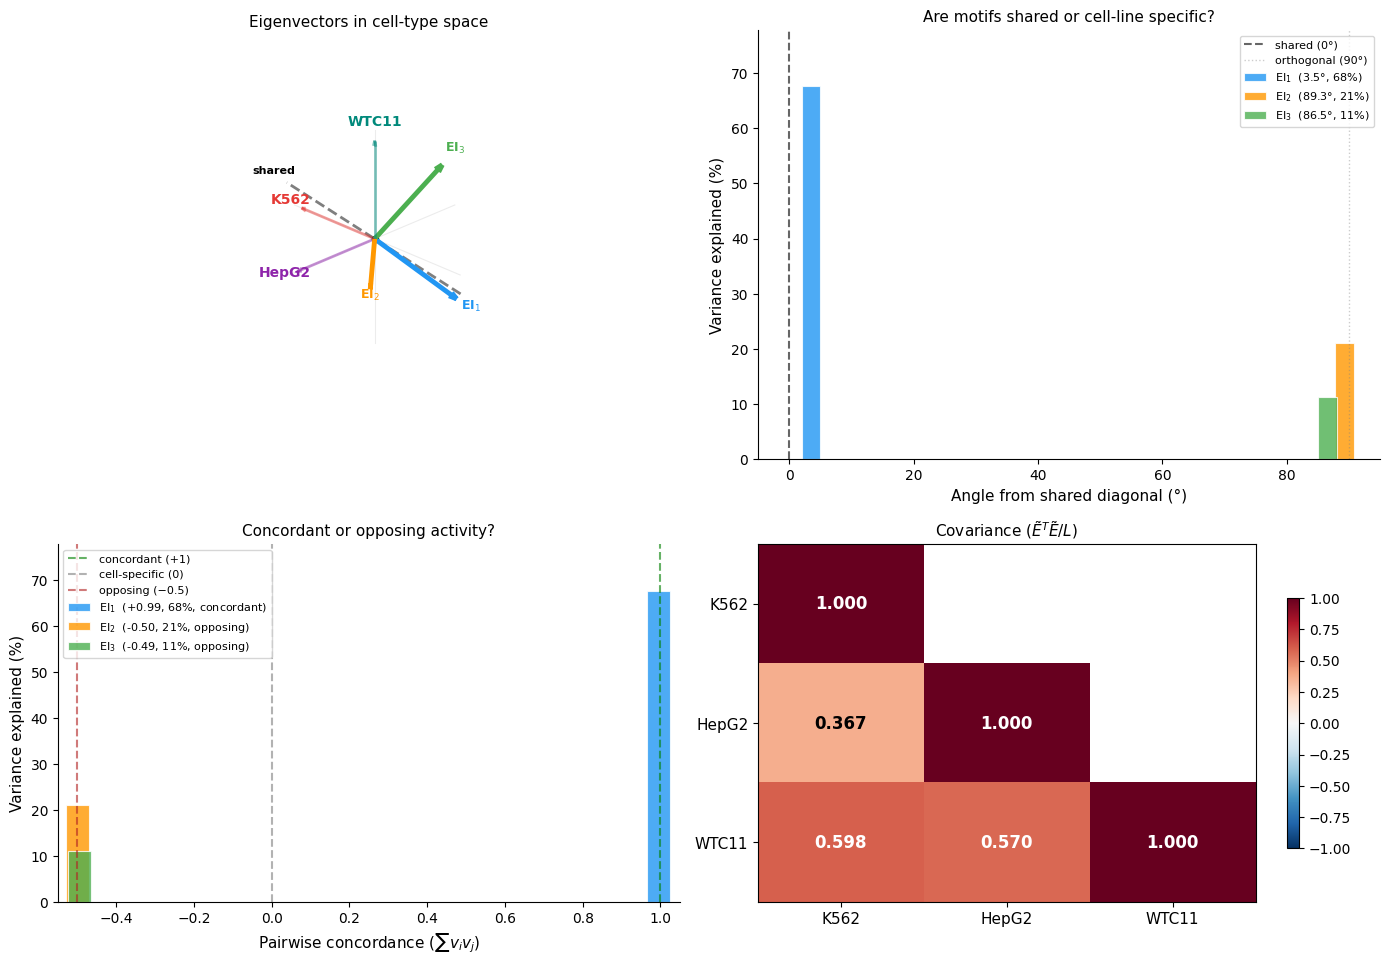

In [6]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

r = em_single.eigen_results[0]
evecs = r['eigenvectors']
evals = r['var_ratio'] * 100
C = r['cov']
ct_names = list(MODEL_NAMES.keys())
ei_colors = ['#2196F3', '#FF9800', '#4CAF50']
ct_colors = ['#E53935', '#8E24AA', '#00897B']

# Reference directions
shared_dir = np.array([1, 1, 1]) / np.sqrt(3)

# Unsigned angle (0-90): sign-invariant, for motif sharing
def unsigned_angle(a, b):
    cos = np.clip(np.abs(np.dot(a, b)), 0, 1)
    return np.degrees(np.arccos(cos))

# Pairwise concordance: sum of v_i * v_j for all pairs
# Sign-invariant: +1 = concordant, 0 = cell-specific, -0.5 = opposing
def pairwise_concordance(v):
    s = np.sum(v)
    return (s**2 - np.sum(v**2)) / 2

# Build figure
fig = plt.figure(figsize=(14, 10))
gs = fig.add_gridspec(2, 2, height_ratios=[1.2, 1])

# --- Panel 1 (top-left): 3D eigenvectors ---
ax3d = fig.add_subplot(gs[0, 0], projection='3d')

for ci in range(3):
    line = np.zeros((2, 3))
    line[0, ci] = -1.1; line[1, ci] = 1.1
    ax3d.plot(line[:, 0], line[:, 1], line[:, 2],
              color='gray', alpha=0.15, linewidth=0.8)
ax3d.scatter([0], [0], [0], c='k', s=20, zorder=5)

diag = shared_dir
ax3d.plot([-diag[0], diag[0]], [-diag[1], diag[1]], [-diag[2], diag[2]],
          'k--', alpha=0.5, linewidth=2)
ax3d.text(diag[0]*1.15, diag[1]*1.15, diag[2]*1.15, 'shared',
          fontsize=8, ha='center', color='black', fontweight='bold')

for ci in range(3):
    e = np.zeros(3); e[ci] = 1.0
    ax3d.quiver(0, 0, 0, e[0], e[1], e[2],
                color=ct_colors[ci], alpha=0.5, arrow_length_ratio=0.06,
                linewidth=2)
    ax3d.text(*(e * 1.15), ct_names[ci], fontsize=10, color=ct_colors[ci],
              fontweight='bold', ha='center')

for ei in range(3):
    v = evecs[:, ei]
    ax3d.quiver(0, 0, 0, v[0], v[1], v[2],
                color=ei_colors[ei], arrow_length_ratio=0.08, linewidth=3.5)
    ax3d.text(v[0]*1.18, v[1]*1.18, v[2]*1.18,
              f'EI$_{ei+1}$', fontsize=9, fontweight='bold',
              color=ei_colors[ei], ha='center')

ax3d.set_xlim(-1.2, 1.2); ax3d.set_ylim(-1.2, 1.2); ax3d.set_zlim(-1.2, 1.2)
ax3d.set_xlabel(''); ax3d.set_ylabel(''); ax3d.set_zlabel('')
ax3d.set_title('Eigenvectors in cell-type space', fontsize=11, pad=-10)
ax3d.set_box_aspect([1, 1, 1])
ax3d.view_init(elev=25, azim=135)

ax3d.xaxis.pane.fill = False
ax3d.yaxis.pane.fill = False
ax3d.zaxis.pane.fill = False
ax3d.xaxis.pane.set_edgecolor((1, 1, 1, 0))
ax3d.yaxis.pane.set_edgecolor((1, 1, 1, 0))
ax3d.zaxis.pane.set_edgecolor((1, 1, 1, 0))
ax3d.xaxis.line.set_color((1, 1, 1, 0))
ax3d.yaxis.line.set_color((1, 1, 1, 0))
ax3d.zaxis.line.set_color((1, 1, 1, 0))
ax3d.xaxis._axinfo['tick']['inward_factor'] = 0
ax3d.yaxis._axinfo['tick']['inward_factor'] = 0
ax3d.zaxis._axinfo['tick']['inward_factor'] = 0
ax3d.xaxis._axinfo['tick']['outward_factor'] = 0
ax3d.yaxis._axinfo['tick']['outward_factor'] = 0
ax3d.zaxis._axinfo['tick']['outward_factor'] = 0
ax3d.grid(False)
ax3d.set_xticks([]); ax3d.set_yticks([]); ax3d.set_zticks([])

pos = ax3d.get_position()
ax3d.set_position([pos.x0 - 0.05, pos.y0 - 0.03, pos.width + 0.10, pos.height + 0.06])

# --- Compute metrics ---
ei_angles_unsigned = [unsigned_angle(evecs[:, ei], shared_dir) for ei in range(3)]
ei_concordance = [pairwise_concordance(evecs[:, ei]) for ei in range(3)]

# --- Panel 2: Are motifs shared or cell-line specific? (single bars) ---
ax = fig.add_subplot(gs[0, 1])

ax.axvline(0, color='black', alpha=0.6, linewidth=1.5, linestyle='--', label='shared (0\u00b0)')
ax.axvline(90, color='gray', alpha=0.4, linewidth=1, linestyle=':', label='orthogonal (90\u00b0)')

bar_width = 3.0
for ei in range(3):
    ax.bar(ei_angles_unsigned[ei], evals[ei], width=bar_width, color=ei_colors[ei],
           alpha=0.8, edgecolor='white', linewidth=0.8,
           label=f'EI$_{ei+1}$  ({ei_angles_unsigned[ei]:.1f}\u00b0, {evals[ei]:.0f}%)')

ax.set_xlim(-5, 95)
ax.set_ylim(0, max(evals) * 1.15)
ax.set_xlabel('Angle from shared diagonal (\u00b0)', fontsize=11)
ax.set_ylabel('Variance explained (%)', fontsize=11)
ax.set_title('Are motifs shared or cell-line specific?', fontsize=11)
ax.legend(fontsize=8, loc='upper right', framealpha=0.8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# --- Panel 3: Concordant or opposing activity? (single bars) ---
ax = fig.add_subplot(gs[1, 0])

ax.axvline(1.0, color='green', alpha=0.6, linewidth=1.5, linestyle='--',
           label='concordant (+1)')
ax.axvline(0.0, color='gray', alpha=0.6, linewidth=1.5, linestyle='--',
           label='cell-specific (0)')
ax.axvline(-0.5, color='firebrick', alpha=0.6, linewidth=1.5, linestyle='--',
           label='opposing (\u22120.5)')

bar_width_c = 0.06
for ei in range(3):
    conc = ei_concordance[ei]
    if conc > 0.5:
        sign_label = 'concordant'
    elif conc > -0.1:
        sign_label = 'cell-specific'
    else:
        sign_label = 'opposing'
    ax.bar(conc, evals[ei], width=bar_width_c, color=ei_colors[ei],
           alpha=0.8, edgecolor='white', linewidth=0.8,
           label=f'EI$_{ei+1}$  ({conc:+.2f}, {evals[ei]:.0f}%, {sign_label})')

ax.set_xlim(-0.55, 1.05)
ax.set_ylim(0, max(evals) * 1.15)
ax.set_xlabel('Pairwise concordance ($\\sum v_i v_j$)', fontsize=11)
ax.set_ylabel('Variance explained (%)', fontsize=11)
ax.set_title('Concordant or opposing activity?', fontsize=11)
ax.legend(fontsize=8, loc='upper left', framealpha=0.8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# --- Panel 4 (bottom-right): Covariance matrix ---
ax = fig.add_subplot(gs[1, 1])
vmax = np.abs(C).max()
C_masked = np.copy(C).astype(float)
mask_upper = np.triu(np.ones_like(C, dtype=bool), k=1)
C_masked[mask_upper] = np.nan
im = ax.imshow(C_masked, cmap='RdBu_r', vmin=-vmax, vmax=vmax, aspect='auto')
ax.set_xticks(range(3)); ax.set_xticklabels(ct_names, fontsize=11)
ax.set_yticks(range(3)); ax.set_yticklabels(ct_names, fontsize=11)
for i in range(3):
    for j in range(3):
        if j <= i:
            ax.text(j, i, f'{C[i,j]:.3f}', ha='center', va='center',
                    fontsize=12, fontweight='bold',
                    color='white' if abs(C[i,j]) > 0.5 * vmax else 'black')
ax.set_title('Covariance ($\\tilde{E}^T \\tilde{E} / L$)', fontsize=11)
plt.colorbar(im, ax=ax, shrink=0.7)

fig.tight_layout()
plt.show()

(<Figure size 1800x800 with 3 Axes>,
 array([<Axes: title={'center': 'Eigenvector 1 = [K562:-0.56, HepG2:-0.55, WTC11:-0.63]  (68% variance)'}>,
        <Axes: title={'center': 'Eigenvector 2 = [K562:-0.68, HepG2:+0.73, WTC11:-0.03]  (21% variance)'}>,
        <Axes: title={'center': 'Eigenvector 3 = [K562:-0.48, HepG2:-0.41, WTC11:+0.78]  (11% variance)'}, xlabel='Position (230bp enhancer | 36bp promoter | 15bp barcode)'>],
       dtype=object))

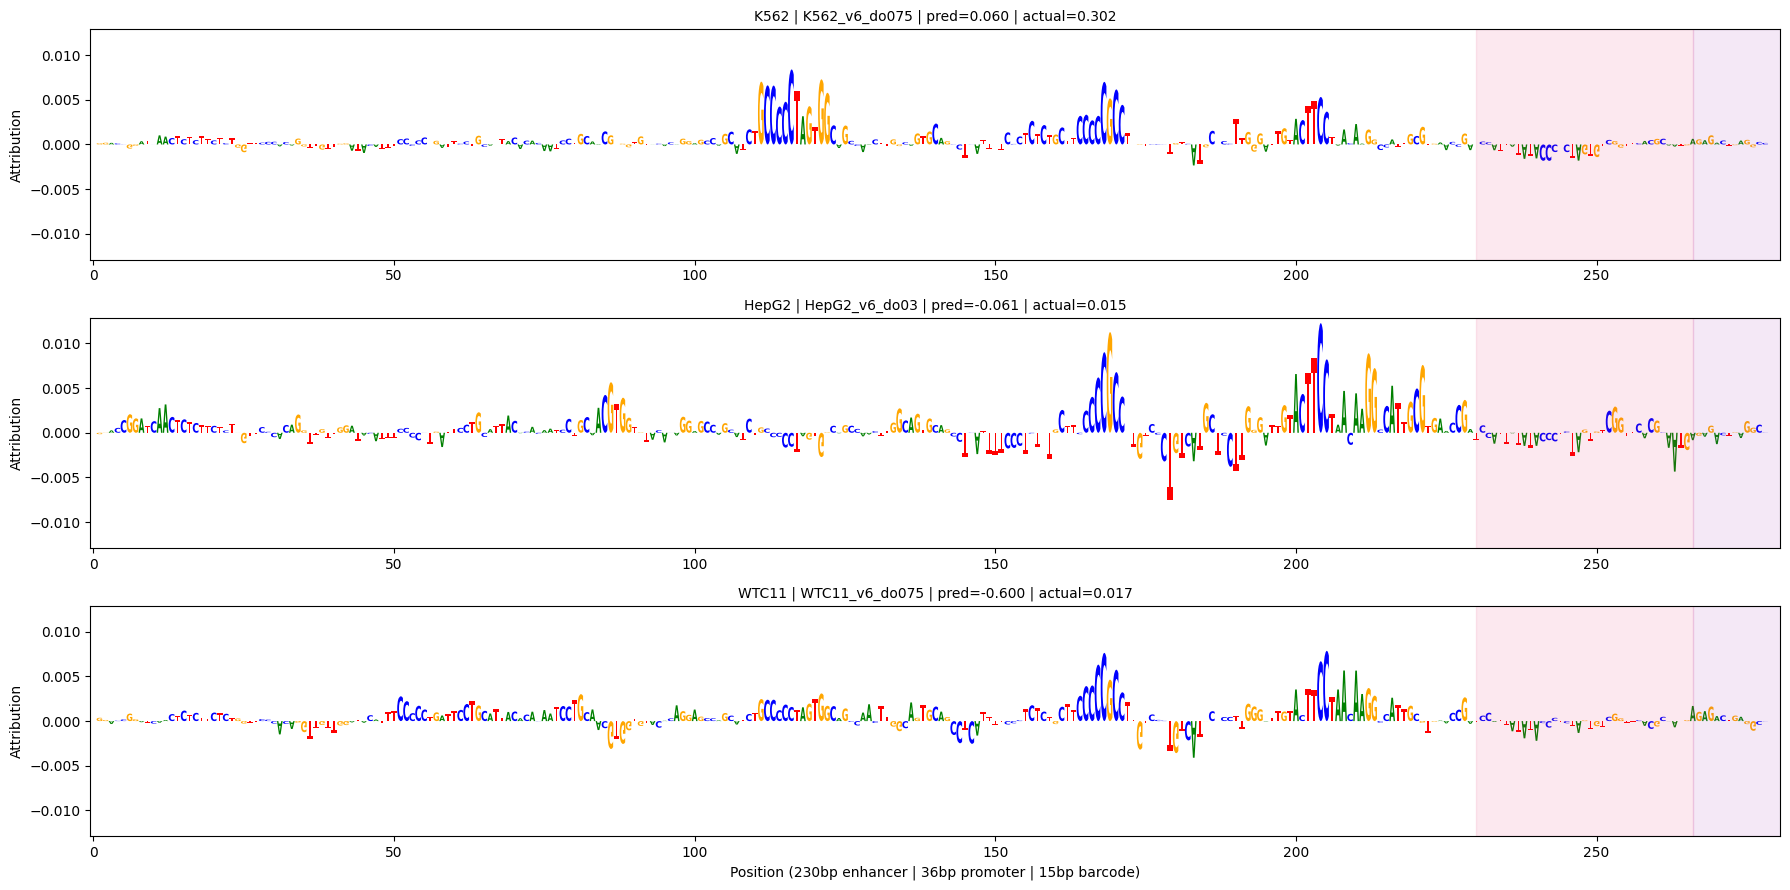

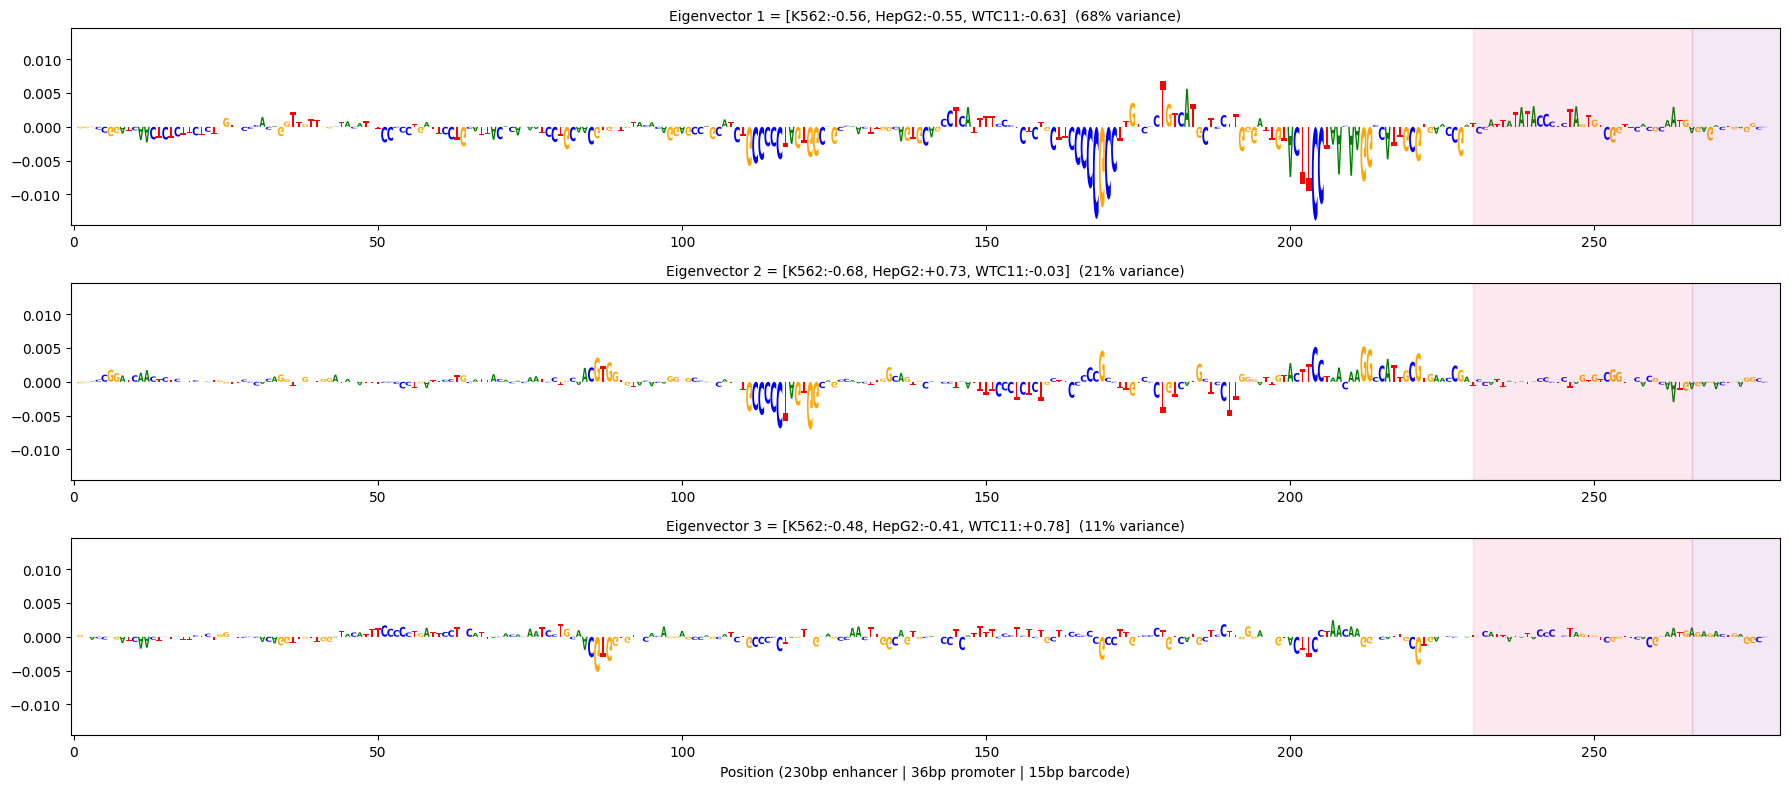

In [7]:
# Attribution logos + EI-weighted logos (slow to render)
# seq_idx=0 because em_single contains only the one sequence selected by ex_idx
em_single.plot_attr_logos(seq_idx=0)
em_single.plot_eigen_logos(seq_idx=0)

## Full library eigendecomposition

Eigendecompose all ~57K sequences. For each sequence we get:
- **EI_1 eigenvector**: the dominant mode of cross-cell-type variation (weights in K562/HepG2/WTC11 space)
- **EI_1 eigenvalue / variance ratio**: how much of the positional covariance is explained by the first mode

We can then use EI_1 eigenvector directions to filter for sequences with specific regulatory patterns (e.g. shared vs cell-type-specific enhancers).

In [8]:
# Eigendecompose the full library
em.eigendecompose(enhancer_only=True)

# Extract EI_1 eigenvectors and variance ratios for all sequences
ei1_vecs = np.array([r['eigenvectors'][:, 0] for r in em.eigen_results])  # (N, 3)
ei1_var = np.array([r['var_ratio'][0] for r in em.eigen_results])          # (N,)

# Add to dataframe for filtering
for ci, ct in enumerate(em.cell_types):
    df[f'EI1_{ct}'] = ei1_vecs[:, ci]
df['EI1_var_explained'] = ei1_var

print(f'EI_1 eigenvectors: {ei1_vecs.shape}')
print(f'EI_1 variance explained: mean={ei1_var.mean():.1%}, median={np.median(ei1_var):.1%}')
print(f'\nEI_1 weight distributions:')
for ci, ct in enumerate(em.cell_types):
    w = ei1_vecs[:, ci]
    print(f'  {ct}: mean={w.mean():.3f}, std={w.std():.3f}, range=[{w.min():.3f}, {w.max():.3f}]')

Eigendecomposed 56974 sequences (enhancer only, 230bp)
EI_1 eigenvectors: (56974, 3)
EI_1 variance explained: mean=64.7%, median=62.9%

EI_1 weight distributions:
  K562: mean=-0.423, std=0.461, range=[-0.707, 0.811]
  HepG2: mean=-0.397, std=0.417, range=[-0.811, 0.784]
  WTC11: mean=-0.352, std=0.391, range=[-0.801, 0.806]


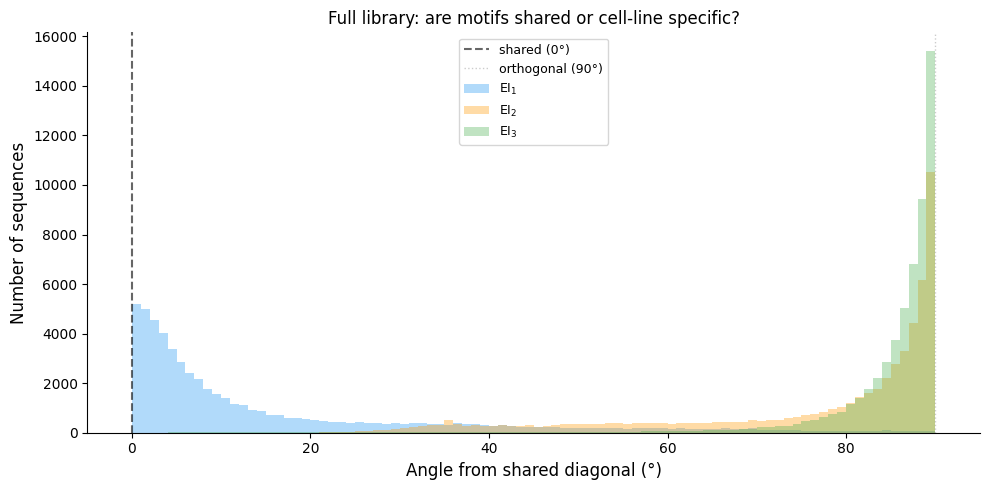

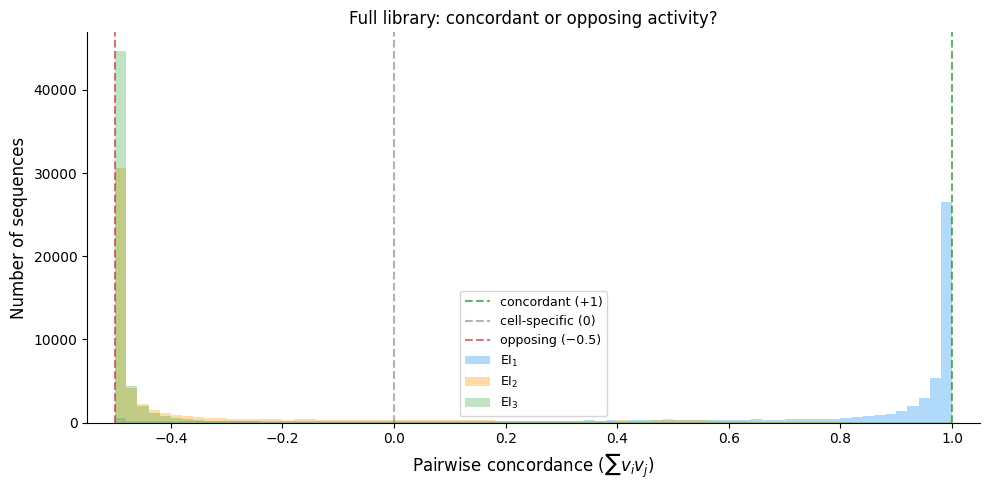

/tmp/slurm_tmp/1025907/ipykernel_4124360/1234052894.py:70: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, labels=['EI$_1$', 'EI$_2$', 'EI$_3$'],


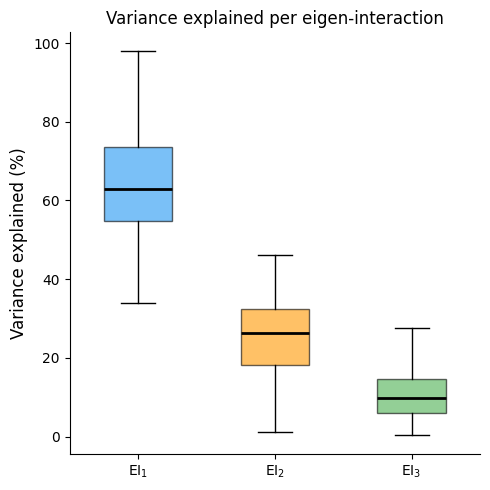

In [9]:
# plot all EIs full library — panels 2 and 3 with all 57K sequences, all 3 EIs
import matplotlib.pyplot as plt

shared_dir = np.array([1, 1, 1]) / np.sqrt(3)
ei_colors = ['#2196F3', '#FF9800', '#4CAF50']

# Extract eigenvectors and variance ratios for all 3 EIs
ei_vecs_all = {}
ei_var_all = {}
for ei in range(3):
    ei_vecs_all[ei] = np.array([r['eigenvectors'][:, ei] for r in em.eigen_results])
    ei_var_all[ei] = np.array([r['var_ratio'][ei] for r in em.eigen_results])

# Compute metrics for all 3 EIs
ei_angles_all = {}     # unsigned angle (motif sharing)
ei_conc_all = {}       # pairwise concordance
for ei in range(3):
    cos_u = np.clip(np.abs(ei_vecs_all[ei] @ shared_dir), 0, 1)
    ei_angles_all[ei] = np.degrees(np.arccos(cos_u))
    s = ei_vecs_all[ei].sum(axis=1)
    ei_conc_all[ei] = (s**2 - np.sum(ei_vecs_all[ei]**2, axis=1)) / 2

# ---- Figure 1: Motif sharing (panel 2) — all 3 EIs ----
fig, ax = plt.subplots(figsize=(10, 5))

ax.axvline(0, color='black', alpha=0.6, linewidth=1.5, linestyle='--', label='shared (0\u00b0)')
ax.axvline(90, color='gray', alpha=0.4, linewidth=1, linestyle=':', label='orthogonal (90\u00b0)')

bins_angle = np.linspace(0, 90, 91)
for ei in range(3):
    ax.hist(ei_angles_all[ei], bins=bins_angle, color=ei_colors[ei],
            alpha=0.35, edgecolor='none', label=f'EI$_{ei+1}$')

ax.set_xlim(-5, 95)
ax.set_xlabel('Angle from shared diagonal (\u00b0)', fontsize=12)
ax.set_ylabel('Number of sequences', fontsize=12)
ax.set_title('Full library: are motifs shared or cell-line specific?', fontsize=12)
ax.legend(fontsize=9, framealpha=0.8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

# ---- Figure 2: Concordance (panel 3) — all 3 EIs ----
fig, ax = plt.subplots(figsize=(10, 5))

ax.axvline(1.0, color='green', alpha=0.6, linewidth=1.5, linestyle='--', label='concordant (+1)')
ax.axvline(0.0, color='gray', alpha=0.6, linewidth=1.5, linestyle='--', label='cell-specific (0)')
ax.axvline(-0.5, color='firebrick', alpha=0.6, linewidth=1.5, linestyle='--', label='opposing (\u22120.5)')

bins_conc = np.linspace(-0.5, 1.0, 76)
for ei in range(3):
    ax.hist(ei_conc_all[ei], bins=bins_conc, color=ei_colors[ei],
            alpha=0.35, edgecolor='none', label=f'EI$_{ei+1}$')

ax.set_xlim(-0.55, 1.05)
ax.set_xlabel('Pairwise concordance ($\\sum v_i v_j$)', fontsize=12)
ax.set_ylabel('Number of sequences', fontsize=12)
ax.set_title('Full library: concordant or opposing activity?', fontsize=12)
ax.legend(fontsize=9, framealpha=0.8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

# ---- Figure 3: Boxplot — variance explained per EI ----
fig, ax = plt.subplots(figsize=(5, 5))

box_data = [ei_var_all[ei] * 100 for ei in range(3)]
bp = ax.boxplot(box_data, labels=['EI$_1$', 'EI$_2$', 'EI$_3$'],
                patch_artist=True, showfliers=False, widths=0.5)
for ei, patch in enumerate(bp['boxes']):
    patch.set_facecolor(ei_colors[ei])
    patch.set_alpha(0.6)
for ei, median in enumerate(bp['medians']):
    median.set_color('black')
    median.set_linewidth(2)

ax.set_ylabel('Variance explained (%)', fontsize=12)
ax.set_title('Variance explained per eigen-interaction', fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

Selected sequences:
  Highest EI$_1$ var (seq 17243):
    name: WTC11_seq13226_F
    category: putative enhancer, WTC11
    EI_1 var: 97.9%, EI_2 var: 1.2%
    K562: act=1.51 pred=0.67 | HepG2: act=1.04 pred=0.82 | WTC11: act=2.26 pred=1.18
  Highest EI$_2$ var (seq 24349):
    name: K562_peak62242
    category: putative enhancer, K562
    EI_1 var: 48.2%, EI_2 var: 46.0%
    K562: act=-0.57 pred=-0.37 | HepG2: act=-0.73 pred=-0.81 | WTC11: act=-0.66 pred=-0.65
  Pos control (seq 56765):
    name: C:SLEA_hg18:chr2:210861483-210861650|8:V_HNF3ALPHA_Q6:TGTTTGCTTTG;23:V_HNF1_C:AG
    category: positive HepG2, Smith
    EI_1 var: 57.8%, EI_2 var: 34.4%
    K562: act=-1.06 pred=-0.97 | HepG2: act=2.17 pred=1.46 | WTC11: act=-1.21 pred=-1.28


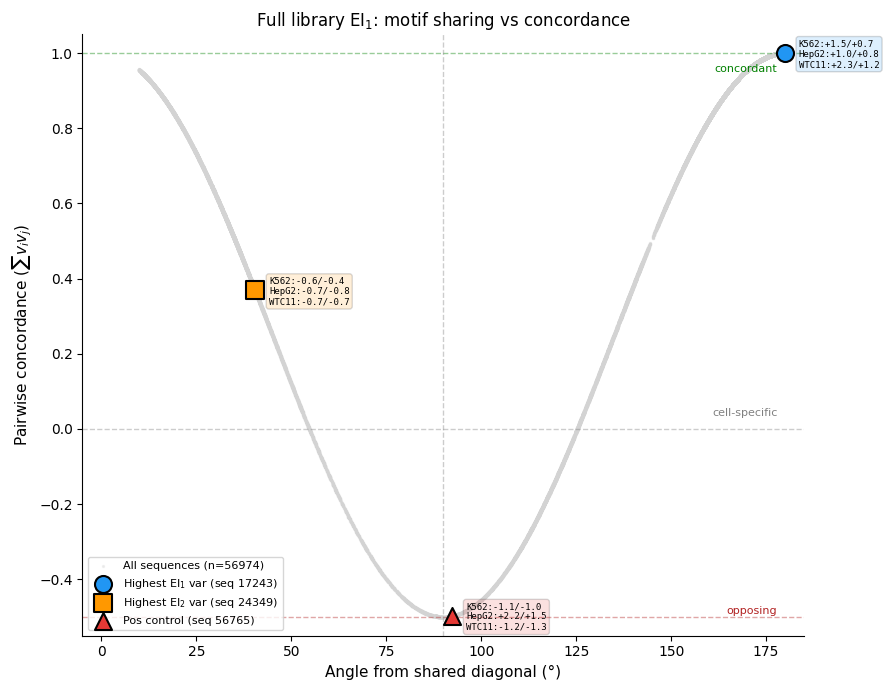

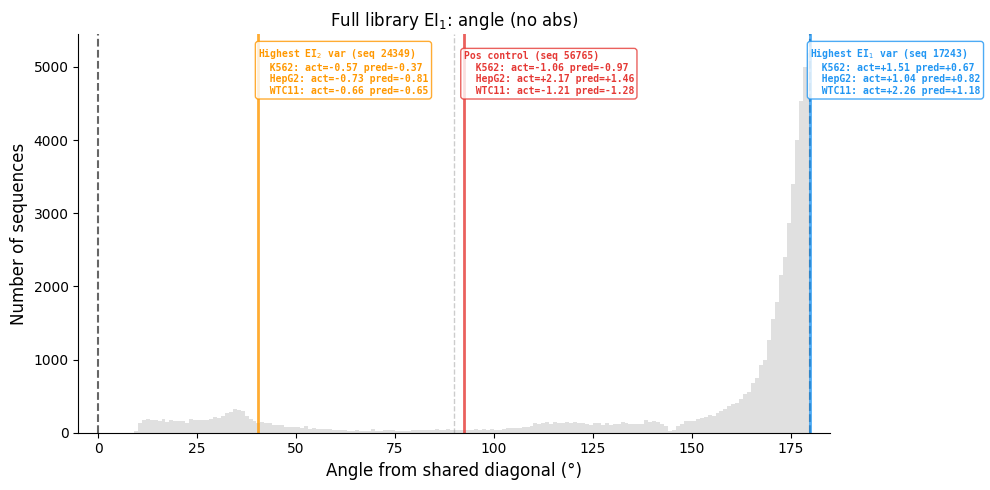

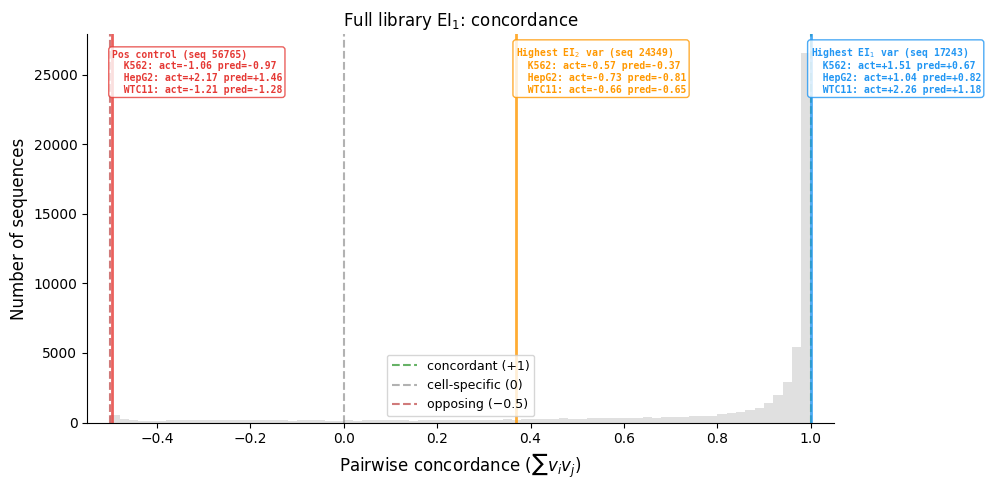

In [10]:
# Select 3 example sequences and plot EI_1s on angle vs concordance + 1D histograms
import matplotlib.pyplot as plt

shared_dir = np.array([1, 1, 1]) / np.sqrt(3)
ct_names = list(MODEL_NAMES.keys())

# a) Select sequences
idx_high_ei1 = np.argmax(ei_var_all[0])
idx_high_ei2 = np.argmax(ei_var_all[1])
pos_ctrl_mask = df['category'].str.contains('positive', case=False, na=False)
pos_ctrl_indices = np.where(pos_ctrl_mask.values)[0]
np.random.seed(42)
idx_pos_ctrl = np.random.choice(pos_ctrl_indices)

selected = [
    ('Highest EI$_1$ var', idx_high_ei1, '#2196F3', 'o'),
    ('Highest EI$_2$ var', idx_high_ei2, '#FF9800', 's'),
    ('Pos control', idx_pos_ctrl, '#E53935', '^'),
]

def activity_str(idx):
    parts = []
    for ct in ct_names:
        actual = df.iloc[idx][f'{ct}_log2FC']
        pred = em.predictions[ct][idx] if ct in em.predictions else float('nan')
        parts.append(f'{ct}: act={actual:.2f} pred={pred:.2f}')
    return ' | '.join(parts)

print('Selected sequences:')
for label, idx, _, _ in selected:
    print(f'  {label} (seq {idx}):')
    print(f'    name: {df.iloc[idx]["name"][:80]}')
    print(f'    category: {df.iloc[idx]["category"]}')
    print(f'    EI_1 var: {ei_var_all[0][idx]*100:.1f}%, EI_2 var: {ei_var_all[1][idx]*100:.1f}%')
    print(f'    {activity_str(idx)}')

# b) Compute raw angle (no abs, 0-180) & concordance for ALL EI_1s
cos_raw_all = np.clip(ei_vecs_all[0] @ shared_dir, -1, 1)
angles_raw_all = np.degrees(np.arccos(cos_raw_all))
s_all = ei_vecs_all[0].sum(axis=1)
conc_all = (s_all**2 - np.sum(ei_vecs_all[0]**2, axis=1)) / 2

# ---- Figure 1: 2D scatter — raw angle vs concordance ----
fig, ax = plt.subplots(figsize=(9, 7))

ax.scatter(angles_raw_all, conc_all, c='lightgray', s=2, alpha=0.3, rasterized=True,
           label=f'All sequences (n={len(angles_raw_all)})')

for label, idx, mc, mk in selected:
    ax.scatter(angles_raw_all[idx], conc_all[idx], c=mc, s=150, marker=mk,
               edgecolors='black', linewidth=1.5, zorder=5,
               label=f'{label} (seq {idx})')
    parts = []
    for ct in ct_names:
        actual = df.iloc[idx][f'{ct}_log2FC']
        pred = em.predictions[ct][idx] if ct in em.predictions else float('nan')
        parts.append(f'{ct}:{actual:+.1f}/{pred:+.1f}')
    ax.annotate('\n'.join(parts),
                xy=(angles_raw_all[idx], conc_all[idx]),
                xytext=(10, -10), textcoords='offset points',
                fontsize=6.5, fontfamily='monospace',
                bbox=dict(boxstyle='round,pad=0.3', facecolor=mc, alpha=0.15))

ax.axhline(1.0, color='green', alpha=0.4, linewidth=1, linestyle='--')
ax.axhline(0.0, color='gray', alpha=0.4, linewidth=1, linestyle='--')
ax.axhline(-0.5, color='firebrick', alpha=0.4, linewidth=1, linestyle='--')
ax.axvline(90, color='gray', alpha=0.4, linewidth=1, linestyle='--')

ax.text(178, 0.97, 'concordant', fontsize=8, color='green', ha='right', va='top')
ax.text(178, 0.03, 'cell-specific', fontsize=8, color='gray', ha='right', va='bottom')
ax.text(178, -0.47, 'opposing', fontsize=8, color='firebrick', ha='right', va='top')

ax.set_xlim(-5, 185); ax.set_ylim(-0.55, 1.05)
ax.set_xlabel('Angle from shared diagonal (\u00b0)', fontsize=11)
ax.set_ylabel('Pairwise concordance ($\\sum v_i v_j$)', fontsize=11)
ax.set_title('Full library EI$_1$: motif sharing vs concordance', fontsize=12)
ax.legend(fontsize=8, framealpha=0.8, loc='lower left')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

# ---- Figure 2: 1D histogram — raw angle (no abs) ----
fig, ax = plt.subplots(figsize=(10, 5))

ax.axvline(0, color='black', alpha=0.6, linewidth=1.5, linestyle='--')
ax.axvline(90, color='gray', alpha=0.4, linewidth=1, linestyle='--')
ax.axvline(180, color='black', alpha=0.6, linewidth=1.5, linestyle='--')

bins_angle = np.linspace(0, 180, 181)
ax.hist(angles_raw_all, bins=bins_angle, color='lightgray', edgecolor='none', alpha=0.7)

for label, idx, mc, mk in selected:
    a = angles_raw_all[idx]
    ax.axvline(a, color=mc, linewidth=2, alpha=0.8)
    parts = [f'{label} (seq {idx})']
    for ct in ct_names:
        actual = df.iloc[idx][f'{ct}_log2FC']
        pred = em.predictions[ct][idx] if ct in em.predictions else float('nan')
        parts.append(f'  {ct}: act={actual:+.2f} pred={pred:+.2f}')
    ax.annotate('\n'.join(parts), xy=(a, ax.get_ylim()[1] * 0.85),
                fontsize=7, fontfamily='monospace', color=mc, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8, edgecolor=mc))

ax.set_xlim(-5, 185)
ax.set_xlabel('Angle from shared diagonal (\u00b0)', fontsize=12)
ax.set_ylabel('Number of sequences', fontsize=12)
ax.set_title('Full library EI$_1$: angle (no abs)', fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

# ---- Figure 3: 1D histogram — pairwise concordance ----
fig, ax = plt.subplots(figsize=(10, 5))

ax.axvline(1.0, color='green', alpha=0.6, linewidth=1.5, linestyle='--', label='concordant (+1)')
ax.axvline(0.0, color='gray', alpha=0.6, linewidth=1.5, linestyle='--', label='cell-specific (0)')
ax.axvline(-0.5, color='firebrick', alpha=0.6, linewidth=1.5, linestyle='--', label='opposing (\u22120.5)')

bins_conc = np.linspace(-0.5, 1.0, 76)
ax.hist(conc_all, bins=bins_conc, color='lightgray', edgecolor='none', alpha=0.7)

for label, idx, mc, mk in selected:
    c = conc_all[idx]
    ax.axvline(c, color=mc, linewidth=2, alpha=0.8)
    parts = [f'{label} (seq {idx})']
    for ct in ct_names:
        actual = df.iloc[idx][f'{ct}_log2FC']
        pred = em.predictions[ct][idx] if ct in em.predictions else float('nan')
        parts.append(f'  {ct}: act={actual:+.2f} pred={pred:+.2f}')
    ax.annotate('\n'.join(parts), xy=(c, ax.get_ylim()[1] * 0.85),
                fontsize=7, fontfamily='monospace', color=mc, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8, edgecolor=mc))

ax.set_xlim(-0.55, 1.05)
ax.set_xlabel('Pairwise concordance ($\\sum v_i v_j$)', fontsize=12)
ax.set_ylabel('Number of sequences', fontsize=12)
ax.set_title('Full library EI$_1$: concordance', fontsize=12)
ax.legend(fontsize=9, framealpha=0.8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

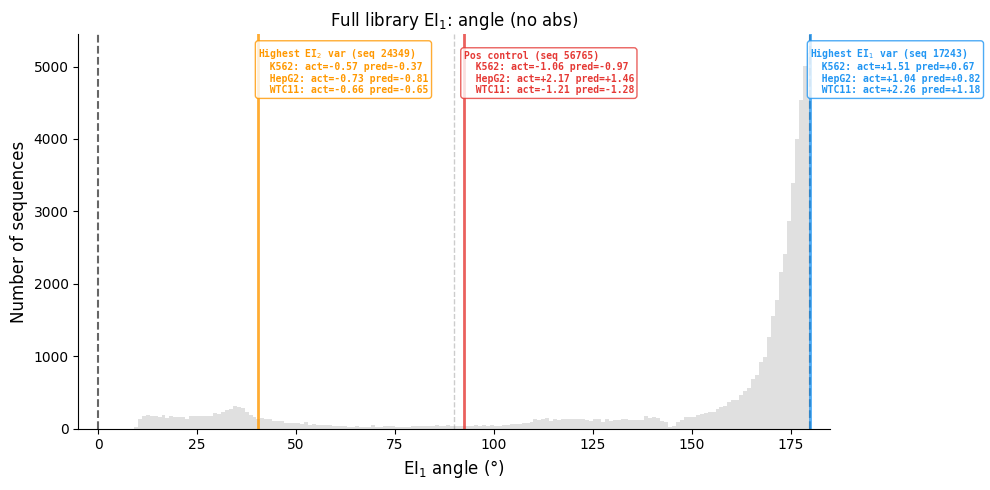

In [11]:
import matplotlib.pyplot as plt

shared_dir = np.array([1, 1, 1]) / np.sqrt(3)

# Raw angle (no abs), 0–180°
cos_raw = np.clip(ei_vecs_all[0] @ shared_dir, -1, 1)
angles_raw = np.degrees(np.arccos(cos_raw))

fig, ax = plt.subplots(figsize=(10, 5))

ax.axvline(0, color='black', alpha=0.6, linewidth=1.5, linestyle='--')
ax.axvline(90, color='gray', alpha=0.4, linewidth=1, linestyle='--')
ax.axvline(180, color='black', alpha=0.6, linewidth=1.5, linestyle='--')

bins_angle = np.linspace(0, 180, 181)
ax.hist(angles_raw, bins=bins_angle, color='lightgray', edgecolor='none', alpha=0.7)

for label, idx, mc, mk in selected:
    a = angles_raw[idx]
    ax.axvline(a, color=mc, linewidth=2, alpha=0.8)
    parts = [f'{label} (seq {idx})']
    for ct in ct_names:
        actual = df.iloc[idx][f'{ct}_log2FC']
        pred = em.predictions[ct][idx] if ct in em.predictions else float('nan')
        parts.append(f'  {ct}: act={actual:+.2f} pred={pred:+.2f}')
    ax.annotate('\n'.join(parts), xy=(a, ax.get_ylim()[1] * 0.85),
                fontsize=7, fontfamily='monospace', color=mc, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8, edgecolor=mc))

ax.set_xlim(-5, 185)
ax.set_xlabel('EI$_1$ angle (°)', fontsize=12)
ax.set_ylabel('Number of sequences', fontsize=12)
ax.set_title('Full library EI$_1$: angle (no abs)', fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()